<div>
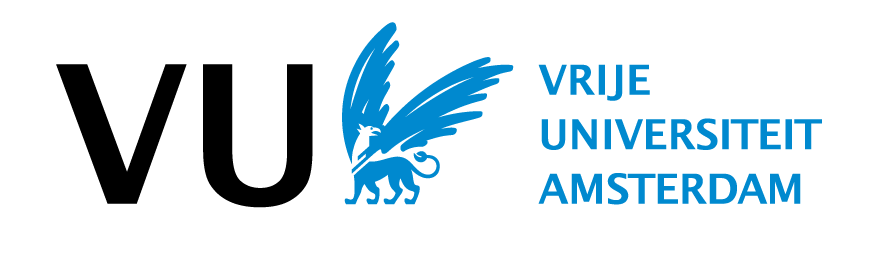
</div>

<div>
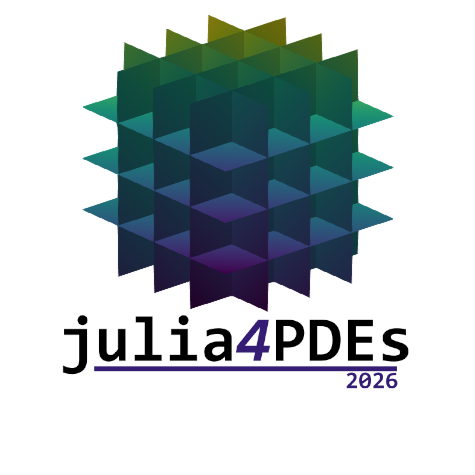
</div>

### Julia4PDEs 2026 workshop

# GalerkinToolkit tutorial


Francesc Verdugo (VU Amsterdam)

2026-03-16

## Contents

In this tutorial, we focus on the pre- and post- processing features of GalerkinToolkit.

In particular:

* How to create/import a mesh
* How to create computational domains
* How to define boundary conditions
* How to create interpolation spaces
* How to assemble a weak form
* How to visualize many types of FEM-related objects using Makie




## Today's example

We consider a simple Stokes flow example to show all these features.


## Importing GalerkinToolkit


The library does not export any name. We always import the library in this way and use the `GT` alias.


In [ ]:
import GalerkinToolkit as GT

## Gmsh meshes

* The extension module `GalerkinToolkitGmshExt` allows you to work with gmsh-generated meshes.
* It gets loaded automatically when `using Gmsh`.

In [ ]:
using Gmsh

## Loading  a mesh from a .msh file


In [ ]:
assets_dir = @__DIR__
msh_file = joinpath(assets_dir,"model.msh")
mesh3d = GT.mesh_from_msh(msh_file)

## Makie.jl visualizations

* The extension module `GalerkinToolkitMakieExt` defines Makie recipes for GT.
* It gets loaded automatically when `using Makie`.
* We define several recipes that will be using along this notebook.


In [ ]:
using Makie
using WGLMakie

## Visualizing a mesh

In [ ]:
fig = Makie.Figure(size=(600,400))
elevation = 0.24π
azimuth = -0.55π
aspect = :data
ax = Makie.Axis3(fig[1,1];aspect=:data,elevation,azimuth)
GT.makie_surfaces!(mesh3d;color=:pink)
GT.makie_edges!(mesh3d;color=:blue)
fig

## Loading and distributing a mesh

* Not all code is distributed yet, but we call already partition meshes.
* The `do`-block is called in one process.
* This process partitions and scatters the mesh to other processes.


In [ ]:
parts = 1:10
mesh_par = GT.with_mesh_partitioner(;parts) do
    GT.mesh_from_msh(msh_file)
end

## PartitionedArrays

* We use `PartitionedArrays`under the hood
* This means that the number of parts and the number of MPI ranks can be different
* Here, we are partitioning into 10 parts on 1 rank.

In [ ]:
GT.node_coordinates(mesh_par)

## Visualizing a distributed mesh

In [ ]:
fig = Makie.Figure(size=(600,400))
ax = Makie.Axis3(fig[1,1];aspect,elevation,azimuth)
color = GT.FaceColor("__OWNER__")
GT.makie_surfaces!(mesh_par;color)
fig

## Using the Julia API of Gmsh

In [ ]:
mesh = GT.with_gmsh() do gmsh
    dim = 2
    gmsh.option.set_number("General.Verbosity", 2)
    rect_tag = gmsh.model.occ.add_rectangle(0, 0, 0, 0.8, 0.41)
    circle_tag = gmsh.model.occ.add_circle(0.2, 0.2, 0, 0.05)
    circle_curve_tag = gmsh.model.occ.add_curve_loop([circle_tag])
    circle_surf_tag = gmsh.model.occ.add_plane_surface([circle_curve_tag])
    gmsh.model.occ.fragment([(dim, rect_tag)], [(dim, circle_surf_tag)],false,true)
    gmsh.model.occ.synchronize()
    gmsh.model.model.add_physical_group(dim, [2], -1, "obstacle")
    gmsh.model.model.add_physical_group(dim, [1,2], -1, "domain")
    gmsh.model.model.add_physical_group(dim-1, [1], -1, "bottom")
    gmsh.model.model.add_physical_group(dim-1, [4], -1, "top")
    gmsh.model.model.add_physical_group(dim-2, [5], -1, "downstream")
    gmsh.option.set_number("Mesh.MeshSizeFromCurvature", 30)
    gmsh.option.set_number("Mesh.MeshSizeMax", 0.05)
    gmsh.model.mesh.generate(dim)
    GT.mesh_from_gmsh(gmsh)
end

This is the mesh we use in today's example.

In [ ]:
fig_size = (700,400)
fig = Makie.Figure(size=fig_size)
axis = (;aspect=Makie.DataAspect())
shading = Makie.NoShading
ax,sc = GT.makie_surfaces(
    fig[1,1],mesh;
    axis,shading,color=:pink)
linewidth = 1
GT.makie_edges!(mesh;linewidth,color=:blue)
fig

## Mesh representation

* A mesh contains faces of different dimensions.
* In this 2d mesh: vertices, edges, and surfaces.


In [ ]:
GT.num_faces(mesh,2)

In [ ]:
GT.num_faces(mesh,1)

In [ ]:
GT.num_faces(mesh,0)

## Visualizing all faces in a mesh

* To be able to see all faces we need to "shrink" them.
* This also illustrate that faces are open sets.
* What is the `dim` argument doing? Why is it not redundant?


In [ ]:
fig = Makie.Figure(size=fig_size)
shrink = 0.7
ax,sc = GT.makie_surfaces(
    fig[1,1],mesh;
    dim=2,shrink,axis,shading,color=:pink)
GT.makie_edges!(
    mesh;
    dim=1,shrink,color=:blue)
markersize=6
GT.makie_vertices!(
    mesh;
    dim=0,shrink,color=:blue,markersize)
fig

## Faces groups

* The mesh contains named groups of faces for modeling purposes
* They are inherited from the "physical groups" in Gmsh.
* Groups are stored dimension by dimension.
* The same group name is allowed in more than one dimension.

In [ ]:
GT.group_faces(mesh,2)

In [ ]:
GT.group_faces(mesh,1)

In [ ]:
GT.group_faces(mesh,0)

## Visualizing the faces in a group

Given a group name, we can visualize which faces are inside/outside this group.


2D Faces (surfaces) in the group `"obstacle"`.

In [ ]:
fig = Makie.Figure(size=fig_size)
colorrange = (0,1)
ax,sc = GT.makie_surfaces(
    fig[1,1],mesh;
    dim=2,axis,shading,
    color=GT.FaceColor("obstacle"))
Makie.Colorbar(fig[1,2],sc;colorrange)
fig

1D faces (edges) in group `"top"`.

In [ ]:
fig = Makie.Figure(size=fig_size)
ax,sc = GT.makie_edges(
    fig[1,1],mesh;
    dim=1,axis,
    shrink,
    color=GT.FaceColor("bottom"))
Makie.Colorbar(fig[1,2],sc;colorrange)
fig

0D faces (vertices) in group `"downstream"`.

In [ ]:
fig = Makie.Figure(size=fig_size)
ax,sc = GT.makie_vertices(
    fig[1,1],mesh;
    dim=0,axis,
    shrink,
    color=GT.FaceColor("downstream"))
Makie.Colorbar(fig[1,2],sc;colorrange)
fig

## Computational domains

* A domain is the union of a subset of the faces in a mesh
* We can create many different domains from the same mesh
* Domains can be created, e.g., from a mesh and group names.

In [ ]:
Ω_s = GT.interior(mesh;group_names=["obstacle"])

In [ ]:
Γ_walls = GT.boundary(mesh;group_names=["top","bottom"])

## Visualizing domains

In [ ]:
fig = Makie.Figure(size=fig_size)
ax,sc = GT.makie_surfaces(
    fig[1,1],Ω_s;
    axis,
    shading,
    color=:pink)
GT.makie_edges!(
    Γ_walls;
    linewidth=4,
    color=:blue)
fig

## Domain algebra: complement

* Our goal is to solve a Stokes flow on the faces outside the obstacle.
* We can use function `GT.complement`.


In [ ]:
Ω_f = GT.complement(Ω_s;group_name="fluid")

In [ ]:
fig = Makie.Figure(size=fig_size)
ax,sc = GT.makie_surfaces(
    fig[1,1],Ω_f;
    axis,shading,color=:pink)
GT.makie_edges!(Γ_walls;linewidth=4,color=:blue)
fig

## Domain algebra: interface

In [ ]:
Γ_fs = GT.interface(Ω_f,Ω_s;group_name="interface")

In [ ]:
fig = Makie.Figure(size=fig_size)
ax,sc = GT.makie_surfaces(
    fig[1,1],Ω_f;
    axis,shading,color=:pink)
GT.makie_edges!(Γ_walls;linewidth=4,color=:blue)
GT.makie_edges!(Γ_fs;linewidth=4,color=:green)
fig

## Domain algebra: boundary

In [ ]:
∂Ω_f = GT.boundary(Ω_f;group_name="fluid_boundary")

In [ ]:
fig = Makie.Figure(size=fig_size)
ax,sc = GT.makie_surfaces(
    fig[1,1],Ω_f;
    axis,shading,color=:pink)
GT.makie_edges!(∂Ω_f;linewidth=4,color=:blue)
fig

## Creating a custom domain

### Step 1: Selecting the faces in the domain

* We need to create a vector of integers containing the face ids
* We can use use a face iterator to build this vector

In [ ]:
∂Ω_f_faces  = GT.each_face(∂Ω_f)

In [ ]:
function inlet(face)
    x = GT.barycenter(face)
    x[1] ≈ 0
end
new_faces = Int32[ GT.id(face) for face in ∂Ω_f_faces if inlet(face)  ]

### Step 2: Creating a new face group

* This is done by adding the vector of face ids to a Dict.
* The key is the group name.


In [ ]:
groups_1d = GT.group_faces(mesh,1)
groups_1d["inlet"] = new_faces
groups_1d

### Step 3: Create the domain

* Using the mesh and one or more domain names.

In [ ]:
Γ_inlet = GT.boundary(mesh;group_names=["inlet"])

In [ ]:
fig = Makie.Figure(size=fig_size)
ax,sc = GT.makie_surfaces(
    fig[1,1],Ω_f;
    axis,shading,color=:pink)
GT.makie_edges!(Γ_walls;linewidth=4,color=:blue)
GT.makie_edges!(Γ_fs;linewidth=4,color=:green)
GT.makie_edges!(Γ_inlet;linewidth=4,color=:cyan)
fig

## Dirichlet boundary

In [ ]:
Γ_diri = GT.boundary(mesh;group_names=["top","bottom","interface","inlet"])

In [ ]:
fig = Makie.Figure(size=fig_size)
ax,sc = GT.makie_surfaces(
    fig[1,1],Ω_f;
    axis,shading,color=:pink)
GT.makie_edges!(Γ_diri;linewidth=4,color=:blue)
fig

## Defining a Dirichlet boundary condition

In [ ]:
using StaticArrays
using LinearAlgebra

In [ ]:
piecewise = Val(true)
u_diri = GT.analytical_field(Γ_diri;piecewise) do x,name
    z = zero(eltype(x))
    if name == "inlet"
        a = 0.41
        b = 4
        r = x[2]
        vx = (b*r*(a-r))/a^2
        SVector((vx,z))
    else
        SVector(z,z)
    end
end

In [ ]:
fig = Makie.Figure(size=fig_size)
GT.makie_surfaces(
    fig[1,1],Ω_f;
    axis,shading,color=:pink)
sc = GT.makie_edges!(
    Γ_diri;
    linewidth=6,
    color= x -> norm(u_diri(x)))
Makie.Colorbar(fig[1,2],sc)
fig

In [ ]:
fig = Makie.Figure(size=fig_size)
GT.makie_surfaces(
    fig[1,1],Ω_f;
    axis,shading,color=:pink)
sc = GT.makie_edges!(
    Γ_diri;
    linewidth=6,
    color= x -> norm(u_diri(x)))
GT.makie_arrows2d!(
    Γ_diri,u_diri;
    color = x -> norm(u_diri(x)),
    refinement=3,
    lengthscale=0.7)
Makie.Colorbar(fig[1,2],sc)
fig

## Interpolation spaces

In [ ]:
k = 2
D = GT.num_dims(mesh)
V = GT.lagrange_space(Ω_f,k;
   tensor_size = Val((D,)),
   dirichlet_boundary =  Γ_diri)

In [ ]:
nodes_coords = GT.node_coordinates(V)
fig = Makie.Figure(size=fig_size)
GT.makie_surfaces(
    fig[1,1],mesh;
    axis,shading,color=:pink)
GT.makie_edges!(mesh;color=:blue)
Makie.scatter!(nodes_coords;color=:green)
fig

## Cartesian product spaces

First, let us create a space for the pressure.


In [ ]:
Q = GT.lagrange_space(Ω_f,k-1)

 Then, we do the Cartesian product

In [ ]:
VxQ = V × Q

## Numerical quadrature

In [ ]:
integration_degree = 2*k
dΩ_f = GT.quadrature(Ω_f,integration_degree)

In [ ]:
fig = Makie.Figure(size=fig_size)
GT.makie_surfaces(
    fig[1,1],mesh;
    axis,shading,color=:pink)
GT.makie_edges!(mesh;linewidth=1,color=:blue)
x_integration = GT.sample(x->x,dΩ_f)
Makie.scatter!(x_integration.data,markersize=5,color=:green)
fig

## Building the problem


Find $(u,p)\in V_0\times Q$ such that

$a((u,p),(v,q)) = l((v,q))-a((u^\text{Dirichlet}_h,0),(v,q))$

for all $(v,q)\in V_0\times Q$


### Dirichlet field

In [ ]:
uhxph_diri = GT.zero_dirichlet_field(Float64,VxQ)
(uh_diri, ph_diri) = uhxph_diri
GT.interpolate_dirichlet!(u_diri,uh_diri)

In [ ]:
fig = Makie.Figure(size=fig_size)
ax,sc = GT.makie_surfaces(
    fig[1,1],Ω_f;
    axis,
    shading,
    color=x->norm(uh_diri(x)))
Makie.Colorbar(fig[1,2],sc)
fig

### Linear problem


Find $(u,p)\in V_0\times Q$ such that

$a((u,p),(v,q)) = l((v,q))-a((u^\text{Dirichlet}_h,0),(v,q))$

for all $(v,q)\in V_0\times Q$

In [ ]:
using SciMLBase

In [ ]:
∇ = GT.jacobian
div(u,x) = tr(∇(u,x))
a = ((u,p),(v,q)) -> GT.∫(
    x-> ∇(v,x)⋅∇(u,x) - div(v,x)*p(x) + q(x)*div(u,x),dΩ_f)
l = ((v,q),) -> 0
p = GT.SciMLBase_LinearProblem(uhxph_diri,a,l)

## Solving the problem

In [ ]:
using LinearSolve

In [ ]:
sol = LinearSolve.solve(p)

In [ ]:
uhxph = GT.solution_field(uhxph_diri,sol)
(uh,ph) = uhxph

## Visualizing the solution

In [ ]:
fig = Makie.Figure(size=fig_size)
ax,sc_p = GT.makie_surfaces(
    fig[1,1],Ω_f;
    axis,
    shading,
    color=ph)
uh_norm = x->norm(uh(x))
sc_u = GT.makie_arrows2d!(
    Ω_f,uh;
    refinement=2,
    lengthscale=0.01,
    color=uh_norm,
    colormap=:grays,
    shaftlength = 20)
Makie.Colorbar(fig[1,2],sc_p)
Makie.Colorbar(fig[1,3],sc_u)
fig

In [ ]:
fig = Makie.Figure(size=(700,450))
aspect = :data
ax = Makie.Axis3(fig[1,1];aspect=:data)
GT.makie_surfaces!(
    Ω_f;
    color=uh_norm,
    refinement=2,
    warp_by_scalar=ph,
    warp_scale=0.001)
fig

## Bonus: Dirichlet function by solving a PDE

In [ ]:
∂Γ_inlet = GT.boundary(Γ_inlet;group_name="inlet_boundary")

In [ ]:
fig = Makie.Figure(size=fig_size)
GT.makie_surfaces(
    fig[1,1],Ω_f;
    axis,shading,color=:pink)
GT.makie_edges!(Γ_inlet;linewidth=4,color=:cyan)
GT.makie_vertices!(∂Γ_inlet;color=:red,markersize=12)
fig

## Interpolation space on the inlet

In [ ]:
k_inlet = 4
V_inlet = GT.lagrange_space(
    Γ_inlet,k_inlet;
    tensor_size=Val((D,)),
    dirichlet_boundary=∂Γ_inlet)

In [ ]:
nodes_coords_inlet = GT.node_coordinates(V_inlet)
fig = Makie.Figure(size=fig_size)
GT.makie_surfaces(
    fig[1,1],mesh;
    axis,shading,color=:pink)
GT.makie_edges!(mesh;color=:blue)
Makie.scatter!(nodes_coords_inlet;color=:green)
fig

## Quadrature rule on the inlet

In [ ]:
dΓ_inlet = GT.quadrature(Γ_inlet,2*k_inlet)

In [ ]:
fig = Makie.Figure(size=fig_size)
GT.makie_surfaces(
    fig[1,1],mesh;
    axis,shading,color=:pink)
GT.makie_edges!(mesh;linewidth=1,color=:blue)
x_integration = GT.sample(x->x,dΓ_inlet)
Makie.scatter!(x_integration.data,color=:green)
fig

## Solving the problem on the inlet

In [ ]:
using SciMLBase
using LinearSolve
using LinearAlgebra
using StaticArrays
∇ = GT.jacobian
s = GT.analytical_field(x->SVector(1,0),Γ_inlet)
a2 = (u,v) -> GT.∫(x->∇(u,x)⋅∇(v,x),dΓ_inlet)
l2 = v -> GT.∫(x->s(x)⋅v(x),dΓ_inlet)
p2 = GT.SciMLBase_LinearProblem(Float64,V_inlet,a2,l2)
sol2 = LinearSolve.solve(p2)
uh_inlet = GT.solution_field(V_inlet,sol2)

In [ ]:
fig = Makie.Figure(size=fig_size)
GT.makie_surfaces(
    fig[1,1],Ω_f;
    axis,shading,color=:pink)
norm_uh_inlet = x->norm(uh_inlet(x))
GT.makie_edges!(Γ_inlet;linewidth=4,color=norm_uh_inlet)
GT.makie_arrows2d!(Γ_inlet,uh_inlet;color=norm_uh_inlet,refinement=3,lengthscale=10)
GT.makie_vertices!(∂Γ_inlet;color=:red,markersize=12)
fig

## Dirichlet field

In [ ]:
uhxph_diri_2 = GT.zero_dirichlet_field(Float64,VxQ)
(uh_diri_2, ph_diri_2) = uhxph_diri_2

Note that the interpolation order is different from `uh_inlet` and `uh_diri_2`.

In [ ]:
GT.interpolate_dirichlet!(uh_inlet,uh_diri_2)

In [ ]:
fig = Makie.Figure(size=fig_size)
color = x -> norm(uh_diri_2(x))
ax,sc = GT.makie_surfaces(
    fig[1,1],Ω_f;
    axis,shading,color)
GT.makie_arrows2d!(Ω_f,uh_diri_2;color,refinement=3,lengthscale=3)
Makie.Colorbar(fig[1,2],sc)
fig

## Solving the problem with the new Dirichlet condition

In [ ]:
p_2 = GT.SciMLBase_LinearProblem(uhxph_diri_2,a,l)
sol_2 = LinearSolve.solve(p_2)
uhxph_2 = GT.solution_field(uhxph_diri_2,sol_2)
(uh_2,ph_2) = uhxph_2

In [ ]:
fig = Makie.Figure(size=fig_size)
ax,sc_p = GT.makie_surfaces(
    fig[1,1],Ω_f;
    axis,
    shading,
    color=ph_2)
sc_u = GT.makie_arrows2d!(
    Ω_f,uh_2;
    refinement=2,
    lengthscale=0.5,
    color=x->norm(uh_2(x)),
    colormap=:grays,
    shaftlength = 20)
Makie.Colorbar(fig[1,2],sc_p)
Makie.Colorbar(fig[1,3],sc_u)
fig

In [ ]:
fig = Makie.Figure(size=(700,450))
aspect = :data
ax = Makie.Axis3(fig[1,1];aspect=:data)
sc_u = GT.makie_arrows2d!(
    Ω_f,uh_2;
    refinement=2,
    lengthscale=0.8,
    color=x->norm(uh_2(x)),
    warp_by_scalar = ph,
    warp_scale = 0.001,
    shaftlength = 20)
Makie.Colorbar(fig[1,2],sc_u)
fig

## Summary

* We discussed how to set up FEM simulations with GT
* One can flexibly define complex setups
* Using different domains from the same mesh
* With faces of dimension 0, 1, 2, 3, ...
* And visualize many types of quantities using recipes for Makie.jl


## Next steps

* Go to https://github.com/GalerkinToolkit/GalerkinToolkit.jl (QR)
* Give us a ⭐
* Start exploring the project
* Do you want to become a beta tester? Contact us.


<div>
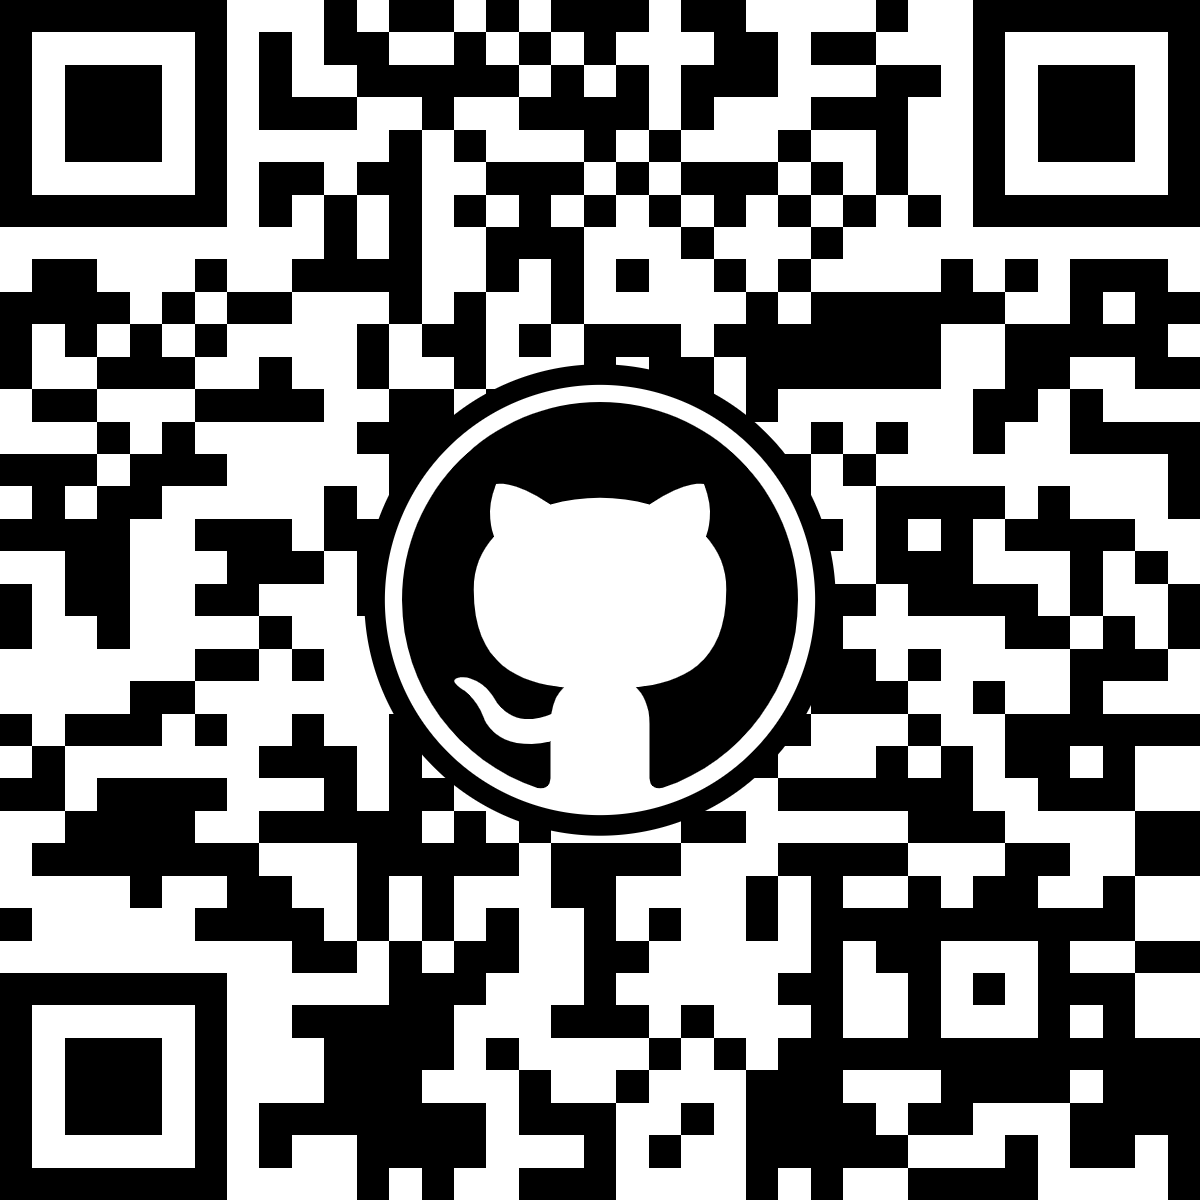
</div>
